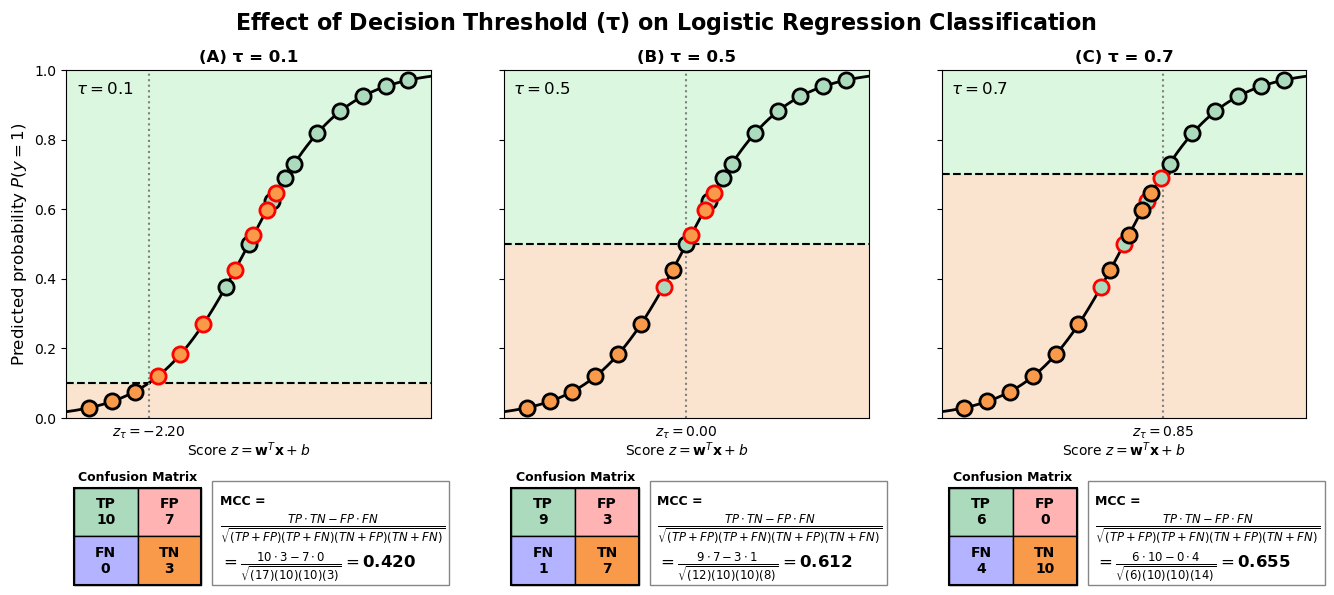

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =====================================================
# SETTINGS
# =====================================================

thresholds = [0.1, 0.5, 0.7]

# Colours (used for points and confusion matrix)
TRUE_POSITIVE_COLOR = "#ABDBBC"     # light green
TRUE_NEGATIVE_COLOR = "#F9994A"     # orange
FALSE_POSITIVE_COLOR = "#FFB3B3"    # light red
FALSE_NEGATIVE_COLOR = "#B3B3FF"    # light blue

# Prediction regions
POSITIVE_REGION = "#D2F6D8"         # pale green
NEGATIVE_REGION = "#F9DEC4"         # creamy orange

# =====================================================
# ENGINEERED DATASET (20 points)
# =====================================================

z_points = np.array([
    3.5,  3.0,  2.5,  2.0,  1.5,  1.0,  0.8,  0.5,  0.0, -0.5,   # positives (10)
   -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.3,  0.1,  0.4,  0.6    # negatives (10)
])

true_labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,   
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0    
])

p_points = 1 / (1 + np.exp(-z_points))

# =====================================================
# MCC FUNCTION
# =====================================================

def compute_mcc(tp, tn, fp, fn):
    numerator = (tp * tn) - (fp * fn)
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    if denominator == 0:
        return 0.0
    return numerator / denominator

# =====================================================
# CONFUSION MATRIX 
# =====================================================

def draw_confusion_matrix(ax, tp, fp, fn, tn):
    # Position - left edge of the subplot area
    x0 = 0.02
    y0 = -0.48
    width = 0.35
    height = 0.28

    # Cell colours
    colors = {
        'TP': TRUE_POSITIVE_COLOR,
        'FP': FALSE_POSITIVE_COLOR,
        'FN': FALSE_NEGATIVE_COLOR,
        'TN': TRUE_NEGATIVE_COLOR
    }

    # Draw four coloured rectangles
    ax.add_patch(Rectangle((x0, y0 + height/2), width/2, height/2,
                           transform=ax.transAxes, facecolor=colors['TP'],
                           edgecolor='black', linewidth=1, clip_on=False))
    ax.add_patch(Rectangle((x0 + width/2, y0 + height/2), width/2, height/2,
                           transform=ax.transAxes, facecolor=colors['FP'],
                           edgecolor='black', linewidth=1, clip_on=False))
    ax.add_patch(Rectangle((x0, y0), width/2, height/2,
                           transform=ax.transAxes, facecolor=colors['FN'],
                           edgecolor='black', linewidth=1, clip_on=False))
    ax.add_patch(Rectangle((x0 + width/2, y0), width/2, height/2,
                           transform=ax.transAxes, facecolor=colors['TN'],
                           edgecolor='black', linewidth=1, clip_on=False))

    # Numbers
    ax.text(x0 + width/4,  y0 + height*0.75, f"TP\n{tp}", ha='center', va='center',
            transform=ax.transAxes, fontsize=10, weight='bold')
    ax.text(x0 + width*3/4, y0 + height*0.75, f"FP\n{fp}", ha='center', va='center',
            transform=ax.transAxes, fontsize=10, weight='bold')
    ax.text(x0 + width/4,  y0 + height*0.25, f"FN\n{fn}", ha='center', va='center',
            transform=ax.transAxes, fontsize=10, weight='bold')
    ax.text(x0 + width*3/4, y0 + height*0.25, f"TN\n{tn}", ha='center', va='center',
            transform=ax.transAxes, fontsize=10, weight='bold')

    # Outer border
    rect = Rectangle((x0, y0), width, height, transform=ax.transAxes,
                     fill=False, edgecolor='black', linewidth=1.5, clip_on=False)
    ax.add_patch(rect)

    # Title
    ax.text(x0 + width/2, y0 + height + 0.02, "Confusion Matrix",
            ha='center', transform=ax.transAxes, fontsize=9, weight='bold')

# =====================================================
# FIGURE
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

z = np.linspace(-4, 4, 1000)
p = 1 / (1 + np.exp(-z))

titles = ["(A) τ = 0.1", "(B) τ = 0.5", "(C) τ = 0.7"]

for ax, tau, title in zip(axes, thresholds, titles):

    # -------------------------------------------------
    # Prediction regions
    # -------------------------------------------------
    ax.axhspan(0, tau, color=NEGATIVE_REGION, alpha=0.8, zorder=0)
    ax.axhspan(tau, 1, color=POSITIVE_REGION, alpha=0.8, zorder=0)

    # -------------------------------------------------
    # Logistic curve
    # -------------------------------------------------
    ax.plot(z, p, color="black", lw=2)

    # Threshold line
    ax.axhline(tau, color="black", ls="--")

    # Decision boundary
    z_tau = np.log(tau / (1 - tau))
    ax.axvline(z_tau, color="gray", ls=":")

    # -------------------------------------------------
    # Predictions and confusion matrix counts
    # -------------------------------------------------
    predictions = (p_points >= tau).astype(int)

    tp = np.sum((true_labels == 1) & (predictions == 1))
    tn = np.sum((true_labels == 0) & (predictions == 0))
    fp = np.sum((true_labels == 0) & (predictions == 1))
    fn = np.sum((true_labels == 1) & (predictions == 0))
    mcc = compute_mcc(tp, tn, fp, fn)

    # -------------------------------------------------
    # Plot data points
    # -------------------------------------------------
    for zz, pp, true_y, pred_y in zip(z_points, p_points, true_labels, predictions):
        face_color = TRUE_POSITIVE_COLOR if true_y == 1 else TRUE_NEGATIVE_COLOR
        edge_color = "black" if true_y == pred_y else "red"
        ax.scatter(zz, pp, s=120, c=face_color, edgecolors=edge_color,
                   linewidths=2, zorder=5)

    # -------------------------------------------------
    # Annotations
    # -------------------------------------------------
    # τ value (top‑left)
    ax.text(-3.8, 0.93, rf"$\tau = {tau}$", fontsize=12, weight="bold")

    # Confusion matrix (left‑aligned)
    draw_confusion_matrix(ax, tp, fp, fn, tn)

    # -------------------------------------------------
    # MCC formula - split into three lines
    # -------------------------------------------------
    cm_x0 = 0.04
    cm_y0 = -0.48
    cm_height = 0.28
    formula_x = 0.42                     # just to the right of the CM
    center_y = cm_y0 + cm_height / 2     # vertical centre of the matrix

    # Line 1: "MCC =" (small, left‑aligned)
    ax.text(formula_x, center_y + 0.1, "MCC =",
            transform=ax.transAxes, ha='left', va='center',
            fontsize=9, weight='bold', clip_on=False)

    # Line 2: generic formula (no numbers, font 12)
    formula_generic = r"$\frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$"
    ax.text(formula_x, center_y + 0.02, formula_generic,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, clip_on=False)

    # Line 3: numeric substitution and result (font 12)
    formula_numeric = rf"$= \frac{{{tp} \cdot {tn} - {fp} \cdot {fn}}}{{\sqrt{{({tp+fp})({tp+fn})({tn+fp})({tn+fn})}}}} = \mathbf{{{mcc:.3f}}}$"
    ax.text(formula_x, center_y - 0.09, formula_numeric,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, clip_on=False)
    
    # Draw box around the formula
    from matplotlib.patches import Rectangle as RectPatch
    # Determine bounding box in axes coords - approximate
    box_x = formula_x - 0.02
    box_y = center_y - 0.14
    box_w = 0.65   # adjust to cover the widest formula
    box_h = 0.3
    ax.add_patch(RectPatch((box_x, box_y), box_w, box_h,
                           transform=ax.transAxes, facecolor='white',
                           edgecolor='gray', linewidth=1, clip_on=False,
                           alpha=0.95, zorder=0))


    # z_tau label - exactly as specified
    ax.text(z_tau, -0.02, rf"$z_\tau={z_tau:.2f}$",
            ha='center', fontsize=10, va='top')

    # -------------------------------------------------
    # Axes labels and limits
    # -------------------------------------------------
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1)
    ax.set_xticks([]) # no x-ticks
    ax.set_xlabel(r"Score $z=\mathbf{w}^{T}\mathbf{x}+b$", labelpad=16)
    ax.set_title(title, fontsize=12, weight="bold")

# =====================================================
# Global labels and layout
# =====================================================

axes[0].set_ylabel(r"Predicted probability $P(y=1)$", fontsize=12)

fig.suptitle("Effect of Decision Threshold ($\\mathbf{\\tau}$) on Logistic Regression Classification",
             fontsize=16, weight="bold")

plt.subplots_adjust(bottom=0.30, wspace=0.20)
plt.show()